In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import classification_report, mean_squared_error
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import torch
import torch.nn as nn
import torch.optim as optim


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


In [7]:

# 1) Load preprocessed frame‐level features (wide) and play outcomes
features = pd.read_csv("../data/play_features.csv")
outcomes = pd.read_csv("../data/play_outcomes.csv")
features = features.rename(columns={"gameId":"game_id","playId":"play_id","frameId":"frame_id"})


In [8]:
# features.loc[[36864]]["player_0_nflId"].item()
test = features[["player_0_nflId"]]
features = features[  test.apply(lambda row: any(isinstance(item, float) for item in row), axis=1)]
outcomes = outcomes[outcomes["game_id"] != "game_id"]

In [9]:
# # fix the line of scrimmage and relative x mistakes
# # Step 1: Recalculate LOS as 10 yards behind the football (assumes player_22 is always the football)
# features['los'] = features['los'] - 10

# # Step 2: Recalculate x_relative for every player
# for i in range(23):  # Players 0 through 22
#     features[f'player_{i}_x_relative'] = features[f'player_{i}_x'] - features['los'] - 10


In [11]:
outcomes[outcomes["pass_result"] == "R"]

,game_id,play_id,start_frame,end_frame,play_type,down,yards_to_go,line_of_scrimmage,yards_gained,pass_result,targeted_receiver_nflId,time_to_throw
35,2022091105,4373,102,179,R,2,10,41,10,R,NaN,NaN
53,2022091101,1192,155,218,R,1,10,68,2,R,NaN,NaN
71,2022091108,3396,96,103,R,1,10,84,4,R,NaN,7.0
78,2022090800,2464,111,175,R,1,15,104,8,R,NaN,NaN
84,2022091109,1544,58,125,R,1,9,101,6,R,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
9643,2022110608,360,112,373,R,3,5,32,21,R,NaN,NaN
9653,2022110603,3064,72,257,R,3,17,46,18,R,NaN,NaN
9702,2022110610,306,131,203,R,2,15,49,16,R,NaN,NaN
9720,2022110300,2926,122,227,R,2,6,56,7,R,NaN,NaN


In [5]:
# Step 1: Recalculate LOS as 10 yards behind the football (assumes player_22 is always the football)
features.head(5)

,player_0_nflId,player_0_displayName_x,player_0_position,player_0_x,player_0_x_relative,player_0_y,player_0_s,player_0_a,player_0_dis,player_0_o,...,player_22_a,player_22_dis,player_22_o,player_22_dir,game_id,play_id,frame_id,yards_to_go,down,los
0,39987.0,Geno Smith,QB,41.74,-21.26,24.19,0.34,0.76,0.03,104.84,...,0.29,0.68,NaN,NaN,2022091200,109,148,3,3,53
1,39987.0,Geno Smith,QB,41.69,-21.31,24.19,0.48,0.96,0.04,101.49,...,0.35,0.64,NaN,NaN,2022091200,109,149,3,3,53
2,39987.0,Geno Smith,QB,41.63,-21.37,24.19,0.67,1.30,0.06,96.85,...,0.46,0.63,NaN,NaN,2022091200,109,150,3,3,53
3,39987.0,Geno Smith,QB,41.56,-21.44,24.19,0.86,1.64,0.08,90.15,...,1.02,0.63,NaN,NaN,2022091200,109,151,3,3,53
4,39987.0,Geno Smith,QB,41.46,-21.54,24.20,1.08,1.64,0.10,94.31,...,1.43,0.62,NaN,NaN,2022091200,109,152,3,3,53


In [124]:
for col in features.select_dtypes(include=['object']).columns:
    features[col] = pd.to_numeric(features[col], errors='coerce')

for col in ["game_id", "play_id", "targeted_receiver_nflId", "start_frame", "end_frame", "down",	"yards_to_go",	"line_of_scrimmage",	"yards_gained","time_to_throw" ]:
    outcomes[col] = pd.to_numeric(outcomes[col], errors='coerce')


In [ ]:

# Merge outcomes onto features
test_df = features.merge(outcomes[["game_id", "play_id", "targeted_receiver_nflId"]], on=["game_id", "play_id"])

# Get receiver index (0–5 for players 5–10)
def get_receiver_index(row):
    for i in range(6, 11):  # player_5 to player_10
        if row[f"player_{i}_nflId"] == row["targeted_receiver_nflId"]:
            return i - 6 
    return -1  # not found

test_df["target_receiver_index"] = test_df.apply(get_receiver_index, axis=1)
features = test_df[test_df["target_receiver_index"] != -1]  # Keep only valid rows
test_df[[ "player_6_nflId", "player_7_nflId", "player_8_nflId", "player_9_nflId", "player_10_nflId", "targeted_receiver_nflId", "target_receiver_index"]]
# test_df[["player5_position", "player6_position", "player7_position", "player8_position", "player9_position", "player10_position", "targeted_receiver_nflId", "target_receiver_index"]]
# test_df[test_df["target_receiver_index"] == -1].drop_duplicates(subset=["game_id", "play_id"]) #these are plays with no receiver


,player_6_nflId,player_7_nflId,player_8_nflId,player_9_nflId,player_10_nflId,targeted_receiver_nflId,target_receiver_index
0,46096.0,46189.0,40026.0,42412.0,47847.0,47847,4
1,46096.0,46189.0,40026.0,42412.0,47847.0,47847,4
2,46096.0,46189.0,40026.0,42412.0,47847.0,47847,4
3,46096.0,46189.0,40026.0,42412.0,47847.0,47847,4
4,46096.0,46189.0,40026.0,42412.0,47847.0,47847,4
5,46096.0,46189.0,40026.0,42412.0,47847.0,47847,4
6,46096.0,46189.0,40026.0,42412.0,47847.0,47847,4
7,46096.0,46189.0,40026.0,42412.0,47847.0,47847,4
8,46096.0,46189.0,40026.0,42412.0,47847.0,47847,4
9,46096.0,46189.0,40026.0,42412.0,47847.0,47847,4


In [ ]:
def add_target_onehot(X, target_idx_col):
    target_onehot = np.zeros((len(X), 5))
    target_indices = X[target_idx_col].values.astype(int)
    for i, idx in enumerate(target_indices):
        target_onehot[i, idx] = 1
    return np.concatenate([X.drop(columns=[target_idx_col]).values, target_onehot], axis=1)

add_target_onehot(test_df.head(1), "target_receiver_index")

array([[3.99870000e+04,            nan,            nan, 3.44900000e+01,
        4.49000000e+00, 2.42800000e+01, 2.40000000e-01, 3.50000000e-01,
        2.00000000e-02, 1.14330000e+02, 3.05670000e+02, 4.35370000e+04,
                   nan,            nan, 3.91600000e+01, 9.16000000e+00,
        2.42000000e+01, 3.40000000e-01, 5.10000000e-01, 3.00000000e-02,
        8.30800000e+01, 1.87670000e+02, 4.13100000e+04,            nan,
                   nan, 3.82300000e+01, 8.23000000e+00, 2.27700000e+01,
        3.90000000e-01, 6.90000000e-01, 4.00000000e-02, 1.48000000e+02,
        2.14060000e+02, 4.79070000e+04,            nan,            nan,
        3.85900000e+01, 8.59000000e+00, 2.56100000e+01, 5.50000000e-01,
        9.50000000e-01, 6.00000000e-02, 7.42700000e+01, 3.57660000e+02,
        5.44740000e+04,            nan,            nan, 3.80500000e+01,
        8.05000000e+00, 2.71800000e+01, 5.70000000e-01, 1.11000000e+00,
        5.00000000e-02, 8.83800000e+01, 3.07050000e+02, 5.453700

In [127]:
features["los"].min()

20

In [128]:
# Merge end_frame into features
features = features.merge(
    outcomes[["game_id", "play_id", "end_frame"]],
    on=["game_id", "play_id"],
    how="left"
)

# Filter to only the final frame of each play
last_frame_features = features[features["frame_id"] == features["end_frame"]].copy()

# Optionally, drop 'end_frame' if not needed anymore
last_frame_features.drop(columns=["end_frame"], inplace=True)
features = last_frame_features


In [129]:


# Attributes to extract from the targeted receiver
receiver_attrs = ['x', 'x_relative', 'y', 's', 'a', 'dis', 'o', 'dir']
targeted_features = []

for idx, row in features.iterrows():
    target_idx = int(row['target_receiver_index'])

    if 0 <= target_idx <= 4:
        # Extract receiver features from row
        features_row = [row.get(f'player_{target_idx + 6}_{attr}', 0.0) for attr in receiver_attrs]
    else:
        # Use zero padding if no targeted receiver
        features_row = [0.0] * len(receiver_attrs)

    targeted_features.append(features_row)

# Create the new target feature columns
targeted_df = pd.DataFrame(targeted_features, columns=[f'target_{attr}' for attr in receiver_attrs])

# Combine with the original features DataFrame
features = pd.concat([features.reset_index(drop=True), targeted_df], axis=1)


In [130]:
features[["target_x_relative", "target_receiver_index", "player_6_x_relative", "player_7_x_relative", "player_8_x_relative", "player_9_x_relative", "player_10_x_relative"]]

,target_x_relative,target_receiver_index,player_6_x_relative,player_7_x_relative,player_8_x_relative,player_9_x_relative,player_10_x_relative
0,14.38,4,4.09,15.25,18.72,15.77,14.38


In [131]:

# features_with_outcomes = features.merge(outcomes[['game_id', 'play_id', 'start_frame', 'end_frame']], 
#                                         on=['game_id', 'play_id'], how='left')

# # Step 2: Check if frame_ids in features are within the start_frame and end_frame
# misaligned = features_with_outcomes[
#     (features_with_outcomes['frame_id'] < features_with_outcomes['start_frame']) |
#     (features_with_outcomes['frame_id'] > features_with_outcomes['end_frame'])
# ]

# if not misaligned.empty:
#     print(f"Warning: Found {len(misaligned)} misaligned frames")
# else:
#     print("All frames in features are within the start and end frames of their respective plays.")


In [132]:
outcomes = outcomes[outcomes["pass_result"].isin(["I", "IN", "C"])]
# Step 3: Merge all outcome columns into features
features = features.merge(outcomes, on=['game_id', 'play_id'], how='left')



# Step 5: Create new feature: frames from snap
features['frames_from_snap'] = features['frame_id'] - features['start_frame']

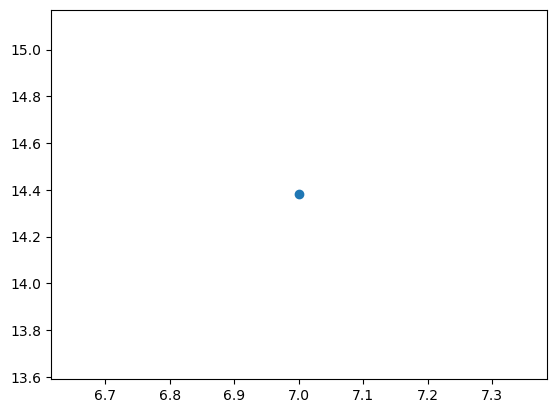

In [ ]:
plt.scatter(features[["yards_gained"]], features[[ "target_x_relative"]])

In [134]:
# 3) Build X, y for two tasks:
#   a) Classification: pass_result (C vs I vs IN)
#   b) Regression: yards_gained

# a) Classification target
# Drop columns that start with 'name_' or 'jersey_', and also 'start_frame' and 'end_frame'
cols_to_drop = [col for col in features.columns 
                if col.endswith('Name_x') or col.endswith('nflId') or col.endswith('displayName_y') or col.endswith('_position')
                or col in ['start_frame', 'end_frame', "game_id","play_id","frame_id","yards_gained","play_type",
                           "pass_result","player22_nflId","targeted_receiver","time_to_throw", "player22_o", 'player_22_nflId',
                           'player_22_position', 'player_22_o', 'player_22_dir'	, 'time_to_throw',
                           "player22_dir",	"player22_position",	"player22_displayName_y"]]

# [2022091104,3662,37266.0,Jason Kelce,106,SNAP,2022-09-11 19:47:01.7,62.0,PHI,right,44.7,28.39,0.28,0.78,0.03,49.59,10.96,ball_snap,C,Jason Kelce]

clf_df = features.dropna(subset=["pass_result"]).copy()
X_clf = clf_df.drop(columns=cols_to_drop)
y_clf = clf_df["pass_result"]
le = LabelEncoder()
y_clf_enc = le.fit_transform(y_clf)  # e.g. ['C','I','IN']→[0,1,2]

# b) Regression target
reg_df = features[features["pass_result"] == 'C'].copy()

X_reg = reg_df.drop(columns=cols_to_drop)
y_reg = reg_df["yards_gained"]

(array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

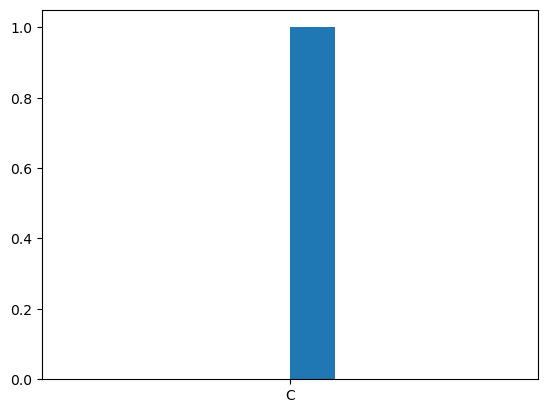

In [ ]:
plt.hist(y_clf)

In [136]:

# 4) Train/test split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf_enc, test_size=0.2, random_state=42, stratify=y_clf_enc
)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

ValueError: With n_samples=1, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [62]:
# Xc_train.iloc[:, 30:50].dtypes
yc_train.shape
type(Xc_train)

pandas.core.frame.DataFrame

In [63]:

for i in outcomes.columns:
  print(i)


game_id
play_id
start_frame
end_frame
play_type
down
yards_to_go
line_of_scrimmage
yards_gained
pass_result
targeted_receiver_nflId
time_to_throw


In [64]:
# 5) Scale features
scaler_c = StandardScaler().fit(Xc_train)
Xc_train_s = scaler_c.transform(Xc_train)
Xc_test_s  = scaler_c.transform(Xc_test)

scaler_r = StandardScaler().fit(Xr_train)
Xr_train_s = scaler_r.transform(Xr_train)
Xr_test_s  = scaler_r.transform(Xr_test)

In [ ]:
# 6a) Train classifier
clf = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=42
)
clf.fit(Xc_train_s, yc_train)

# 6b) Train regressor
reg = MLPRegressor(
    hidden_layer_sizes=(128,64),
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=42
)
reg.fit(Xr_train_s, yr_train)

MLPRegressor(hidden_layer_sizes=(128, 64), random_state=42)

In [ ]:








# 7a) Evaluate classifier
yc_pred = clf.predict(Xc_test_s)
print("=== Classification Report (pass_result) ===")
print(classification_report(yc_test, yc_pred, target_names=le.classes_))

# 7b) Evaluate regressor
yr_pred = reg.predict(Xr_test_s)
mse = mean_squared_error(yr_test, yr_pred)
print(f"=== Regression MSE (yards_gained): {mse:.2f} ===")


=== Classification Report (pass_result) ===
              precision    recall  f1-score   support

           C       0.71      0.77      0.74      1064
           I       0.39      0.34      0.36       485
          IN       0.07      0.03      0.04        36

    accuracy                           0.62      1585
   macro avg       0.39      0.38      0.38      1585
weighted avg       0.60      0.62      0.60      1585

=== Regression MSE (yards_gained): 119.56 ===


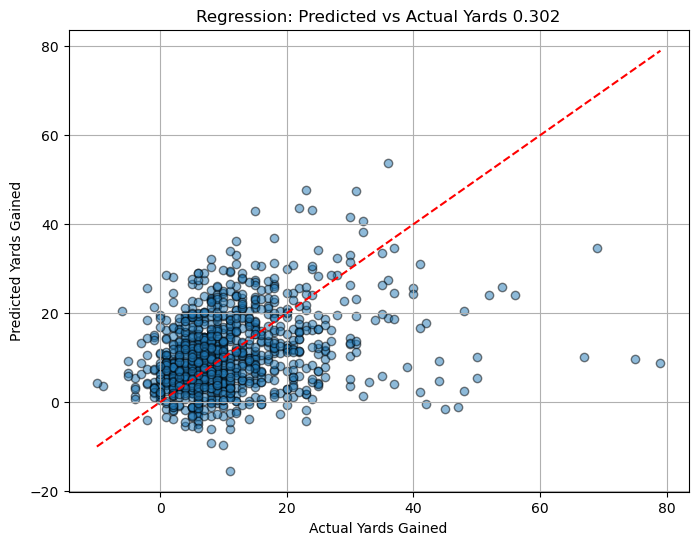

In [67]:

# plt.scatter(yr_test, yr_pred,s=1)

corr, _ = pearsonr(yr_test, yr_pred)


plt.figure(figsize=(8, 6))
plt.scatter(yr_test, yr_pred, alpha=0.5, edgecolors='k')
plt.plot([min(yr_test), max(yr_test)], [min(yr_test), max(yr_test)], 'r--')  # Ideal line
plt.xlabel("Actual Yards Gained")
plt.ylabel("Predicted Yards Gained")
plt.title(f"Regression: Predicted vs Actual Yards {corr:.3f}")
plt.grid(True)
plt.show()

(array([1148.,    0.,    0.,    0.,    0.,  422.,    0.,    0.,    0.,
          15.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

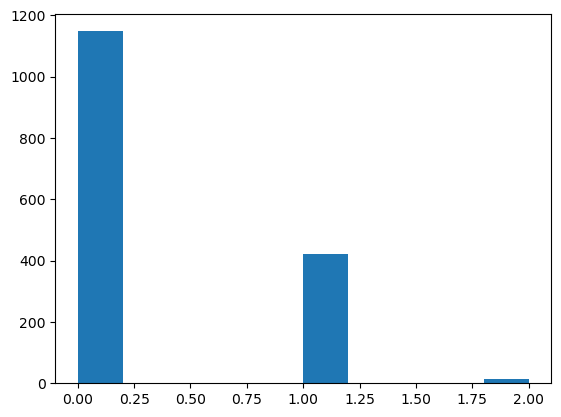

In [68]:
plt.hist(yc_pred)

In [69]:


class CustomNet(nn.Module):
    def __init__(self, input_dim, num_classes=5, dropout_rate=0.4):
        super(CustomNet, self).__init__()

        # Input -> 230
        self.input_layer = nn.Linear(input_dim, 230)
        self.bn0 = nn.BatchNorm1d(230)

        # 230 -> 256
        self.hidden_layer1 = nn.Linear(230, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(dropout_rate)

        # 256 -> 128
        self.hidden_layer2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(dropout_rate)

        # Output layers
        self.class_output = nn.Linear(128, num_classes)
        self.reg_output = nn.Linear(128, 1)

        # Activations
        self.act = nn.LeakyReLU()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.bn0(x)
        
        x = self.act(self.hidden_layer1(x))
        x = self.bn1(x)
        x = self.dropout1(x)
        
        x = self.act(self.hidden_layer2(x))
        x = self.bn2(x)
        x = self.dropout2(x)
        
        class_output = self.class_output(x)
        reg_output = self.reg_output(x)

        return class_output, reg_output


model = CustomNet(input_dim=Xc_train.shape[1])
criterion_class = nn.CrossEntropyLoss()
criterion_reg = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)





In [70]:


# # Training loop
# for epoch in range(200):
#     model.train()
#     total_loss = 0
#     for X_batch, y_class, y_reg in train_loader:
#         optimizer.zero_grad()
        
#         # Forward pass
#         class_pred, reg_pred = model(X_batch)
        
#         # Compute losses
#         loss_class = criterion_class(class_pred, y_class)
#         loss_reg = criterion_reg(reg_pred, y_reg)
        
#         # Total loss (you can weight the losses differently if needed)
#         total_loss = loss_class + loss_reg
        
#         # Backward pass and optimization
#         total_loss.backward()
#         optimizer.step()
        
#     print(f"Epoch {epoch + 1}/{20}, Loss: {total_loss.item():.4f}")


In [71]:
# Assuming you have your training data in Xc_train, yc_train, Xr_train, yr_train
Xc_train_np = Xc_train.to_numpy() if hasattr(Xc_train, "to_numpy") else Xc_train
yc_train_np = yc_train.to_numpy() if hasattr(yc_train, "to_numpy") else yc_train
yr_train_np = yr_train.to_numpy() if hasattr(yr_train, "to_numpy") else yr_train
Xr_train_np = Xr_train.to_numpy() if hasattr(Xr_train, "to_numpy") else Xr_train


# Convert to torch tensors
Xc_train_tensor = torch.tensor(Xc_train_np, dtype=torch.float32)
Xr_train_tensor = torch.tensor(Xr_train_np, dtype=torch.float32)

yc_train_tensor = torch.tensor(yc_train_np, dtype=torch.long)  # For classification (long type)
yr_train_tensor = torch.tensor(yr_train_np, dtype=torch.float32).unsqueeze(1)  # For regression (float)

# Create DataLoader
clf_train_dataset = torch.utils.data.TensorDataset(Xc_train_tensor, yc_train_tensor)
clf_loader = torch.utils.data.DataLoader(clf_train_dataset, batch_size=64, shuffle=True)


# Regression DataLoader (only completions)
reg_dataset = torch.utils.data.TensorDataset(Xr_train_tensor, yr_train_tensor)
reg_loader = torch.utils.data.DataLoader(reg_dataset, batch_size=64, shuffle=True)

In [72]:
# Convert test data to numpy if needed
Xc_test_np = Xc_test.to_numpy() if hasattr(Xc_test, "to_numpy") else Xc_test
yc_test_np = yc_test.to_numpy() if hasattr(yc_test, "to_numpy") else yc_test

Xr_test_np = Xr_test.to_numpy() if hasattr(Xr_test, "to_numpy") else Xr_test
yr_test_np = yr_test.to_numpy() if hasattr(yr_test, "to_numpy") else yr_test

# Convert to torch tensors
Xc_test_tensor = torch.tensor(Xc_test_np, dtype=torch.float32)
yc_test_tensor = torch.tensor(yc_test_np, dtype=torch.long)

Xr_test_tensor = torch.tensor(Xr_test_np, dtype=torch.float32)
yr_test_tensor = torch.tensor(yr_test_np, dtype=torch.float32).unsqueeze(1)

# Create test datasets and dataloaders
clf_test_dataset = torch.utils.data.TensorDataset(Xc_test_tensor, yc_test_tensor)
clf_test_loader = torch.utils.data.DataLoader(clf_test_dataset, batch_size=64, shuffle=False)

reg_test_dataset = torch.utils.data.TensorDataset(Xr_test_tensor, yr_test_tensor)
reg_test_loader = torch.utils.data.DataLoader(reg_test_dataset, batch_size=64, shuffle=False)


In [73]:
type(yc_train)

numpy.ndarray

In [ ]:

NUM_EPOCHS = 100
# Training loop
for epoch in range(NUM_EPOCHS):
    model.train()

    total_loss_class = 0
    total_loss_reg = 0

    # Classification training
    for X_batch, y_batch in clf_loader:
        optimizer.zero_grad()
        class_pred, _ = model(X_batch)
        loss = criterion_class(class_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss_class += loss.item()

    # Regression training (only on completions)
    for X_batch, y_batch in reg_loader:
        optimizer.zero_grad()
        _, reg_pred = model(X_batch)
        loss = criterion_reg(reg_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss_reg += loss.item()

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Class Loss: {total_loss_class:.4f} | Reg Loss: {total_loss_reg:.4f}")

Epoch 1/100 | Class Loss: 173.6543 | Reg Loss: 721.4934
Epoch 2/100 | Class Loss: 164.5384 | Reg Loss: 719.4380
Epoch 3/100 | Class Loss: 158.5355 | Reg Loss: 715.7610
Epoch 4/100 | Class Loss: 153.1140 | Reg Loss: 708.4961
Epoch 5/100 | Class Loss: 148.6706 | Reg Loss: 700.9267
Epoch 6/100 | Class Loss: 142.2965 | Reg Loss: 692.5301
Epoch 7/100 | Class Loss: 137.1334 | Reg Loss: 687.8131
Epoch 8/100 | Class Loss: 130.0129 | Reg Loss: 675.4087
Epoch 9/100 | Class Loss: 122.9812 | Reg Loss: 665.4880
Epoch 10/100 | Class Loss: 116.1426 | Reg Loss: 651.9376
Epoch 11/100 | Class Loss: 109.7933 | Reg Loss: 638.9416
Epoch 12/100 | Class Loss: 102.2277 | Reg Loss: 626.1746
Epoch 13/100 | Class Loss: 97.8677 | Reg Loss: 607.5384
Epoch 14/100 | Class Loss: 93.5344 | Reg Loss: 592.2213
Epoch 15/100 | Class Loss: 89.0990 | Reg Loss: 575.5970
Epoch 16/100 | Class Loss: 86.9169 | Reg Loss: 558.6298
Epoch 17/100 | Class Loss: 83.0787 | Reg Loss: 540.7019
Epoch 18/100 | Class Loss: 81.2018 | Reg Loss

In [75]:
# Convert test sets to NumPy arrays if needed
Xc_test_np = Xc_test.to_numpy() if hasattr(Xc_test, "to_numpy") else Xc_test
yc_test_np = yc_test.to_numpy() if hasattr(yc_test, "to_numpy") else yc_test
yr_test_np = yr_test.to_numpy() if hasattr(yr_test, "to_numpy") else yr_test

# Convert to tensors
X_test_tensor = torch.tensor(Xc_test_np, dtype=torch.float32)
yc_test_tensor = torch.tensor(yc_test_np, dtype=torch.long)
yr_test_tensor = torch.tensor(yr_test_np, dtype=torch.float32).unsqueeze(1)


In [76]:
Xc_test_np = X_clf.to_numpy()
yc_test_np = y_clf_enc
yr_test_np = reg_df["yards_gained"].to_numpy()

print(Xc_test_np.shape)
print(yc_test_np.shape)
print(yr_test_np.shape)


(7924, 200)
(7924,)
(5321,)


In [77]:
model.eval()
total_correct = 0
total_class = 0
total_regression_loss = 0

# Lists to store classification outputs
all_probs_complete = []
all_probs_incomplete = []
all_probs_interception = []
all_true_completions = []
all_preds = []
all_labels = []

# ----- Classification Evaluation -----
with torch.no_grad():
    for X_batch, y_batch in clf_test_loader:
        class_logits, _ = model(X_batch)
        class_probs = torch.softmax(class_logits, dim=1)
        class_preds = torch.argmax(class_probs, dim=1)

        total_correct += (class_preds == y_batch).sum().item()
        total_class += y_batch.size(0)

        # Store probabilities for relevant classes
        all_probs_complete.append(class_probs[:, 0].cpu())
        all_probs_incomplete.append(class_probs[:, 1].cpu())
        all_probs_interception.append(class_probs[:, 2].cpu())
        all_preds.append(class_preds.cpu())
        all_labels.append(y_batch.cpu())

        # Store true labels for binary "complete" indicator
        all_true_completions.append((y_batch == 0).int().cpu())

classification_accuracy = total_correct / total_class

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Concatenate batched tensors
prob_complete = torch.cat(all_probs_complete).numpy()
prob_incomplete = torch.cat(all_probs_incomplete).numpy()
prob_interception = torch.cat(all_probs_interception).numpy()
true_complete = torch.cat(all_true_completions).numpy()

# ----- Regression Evaluation -----
all_r_preds = []
all_r_labels = []
with torch.no_grad():
    for X_batch, y_batch in reg_test_loader:
        _, reg_pred = model(X_batch)
        loss = criterion_reg(reg_pred, y_batch)
        total_regression_loss += loss.item() * X_batch.size(0)
        all_r_preds.append(reg_pred.cpu())
        all_r_labels.append(y_batch.cpu())

mse = total_regression_loss / len(reg_test_loader.dataset)
rmse = mse ** 0.5

all_r_preds = torch.cat(all_r_preds).numpy()
all_r_labels = torch.cat(all_r_labels).numpy()

# ----- Print results -----
print(f"Classification Accuracy: {classification_accuracy:.4f}")
print(f"Regression RMSE (only completions): {rmse:.2f} yards")


Classification Accuracy: 0.6669
Regression RMSE (only completions): 2.35 yards


In [78]:
all_r_labels.mean()

10.838498

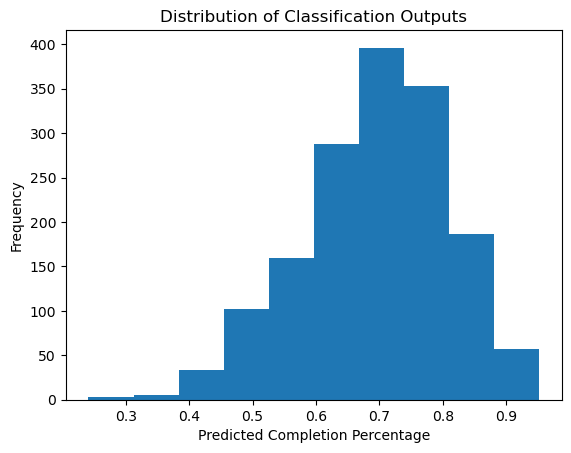

In [ ]:
plt.hist(prob_complete)

plt.xlabel("Predicted Completion Percentage")
plt.ylabel("Frequency")
plt.title("Distribution of Classification Outputs")
plt.show()

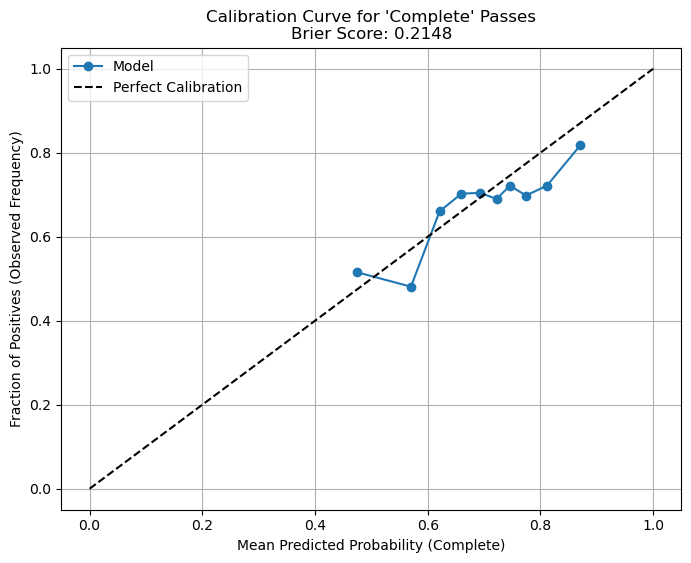

In [ ]:


# Compute Brier score
brier = brier_score_loss(true_complete, prob_complete)

# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    true_complete, prob_complete, 
    n_bins=10, 
    strategy='quantile'
)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "o-", label="Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability (Complete)")
plt.ylabel("Fraction of Positives (Observed Frequency)")
plt.title(f"Calibration Curve for 'Complete' Passes\nBrier Score: {brier:.4f}")
plt.legend()
plt.grid(True)
plt.show()


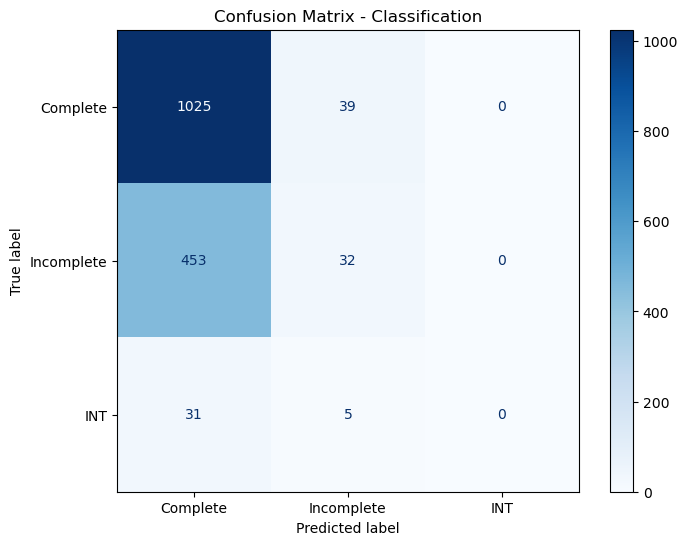

In [81]:


# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Complete", "Incomplete", "INT", ])# "Sack" "Run"

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Classification")
plt.show()


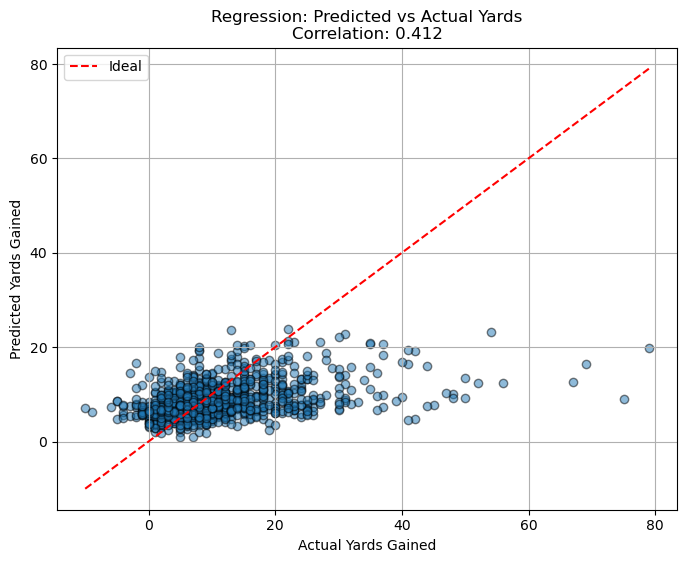

In [ ]:


# Ensure both inputs are float NumPy arrays
labels = np.array(all_r_labels, dtype=np.float32).flatten()
preds = np.array(all_r_preds, dtype=np.float32).flatten()

# Compute Pearson correlation
corr, _ = pearsonr(labels, preds)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(labels, preds, alpha=0.5, edgecolors='k')
plt.plot([labels.min(), labels.max()], [labels.min(), labels.max()], 'r--', label="Ideal")
plt.xlabel("Actual Yards Gained")
plt.ylabel("Predicted Yards Gained")
plt.title(f"Regression: Predicted vs Actual Yards\nCorrelation: {corr:.3f}")
plt.legend()
plt.grid(True)
plt.show()
